# ME 323 Module 1 — Choosing the Ground-Truth Model and the Noise Level
### Faculty notebook (staff only — not for students)

The Module 1 student notebooks "test" two class designs against a frozen
**ground-truth (GT) model** — a surrogate for reality, fit to every beam we
have actually broken. This notebook is the receipts for that model: the full
test campaign, the noise level the repeats support, the candidate model
formulations, how they were scored, and why the winner won. It is
self-contained — it loads the three committed campaign CSVs from GitHub and
reproduces the frozen decision end-to-end (≈10–15 min run time; numpy, pandas,
scikit-learn, matplotlib).

**The data.** A 44-beam Latin-hypercube campaign over the original student
design box (b ∈ [1.25, 7], H_web ∈ [5, 16] mm; flange B = 10, total height
18, span 150 mm), plus a 19-test follow-up batch (repeats at five
geometries, fills in under-sampled zones, a thin-web frontier probe at
b = 1.0–1.1 — below the original box edge, and since 2026-07-20 the anchor
of the widened class box b ∈ [1.0, 7] — and three beams printed with
corrected support settings), plus
the 23-print proper-supports recalibration batch of 2026-07-16.
**85 usable tests in all** = 44 + 19 + 22 (one censored proper-supports LTB
test excluded — it was stopped before failure). Deliberately *not* in the
training pool: the 10-test interleaved support experiment (5 proper + 5
improper supports, all at the (1.3, 12.8) anchor). That is a data-selection
choice, stated here so reviewers see it: it is a controlled A/B block at a
single location, and folding in ten more repeats there would let one anchor
(which already carries 10 training tests across the three batches) dominate
the leave-one-location-out scoring below.

> ⚠ **Handling.** This notebook and the campaign CSVs it loads reveal the
> ground truth the students are graded against. They are shared for faculty
> review while the module is in development and will be removed from the
> public repo before the course goes live. Keep them out of anything students
> receive.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

RAW = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/")
def load(name):
    try:
        df = pd.read_csv(RAW + name); src = "GitHub"
    except Exception:
        df = pd.read_csv("../../data/" + name); src = "local copy"
    print(f"{name}: {len(df)} rows ({src})")
    return df

# geometry / mass model (identical to the student notebooks)
B_FLANGE, TH, L_SPAN = 10.0, 18.0, 150.0
KMASS = 0.2045                      # g/mm^2 of cross-section at 172 mm printed length
B_LO, B_HI, H_LO, H_HI = 1.0, 7.0, 5.0, 16.0    # student design box (widened from b >= 1.25, 2026-07-20)
def mass_g(b, H):
    return KMASS * (b * H + B_FLANGE * (TH - H))

# one master file: all 86 tests from the 150 mm span experiments
# (44-beam campaign + 19 follow-ups + 23 proper-supports prints), with the
# uniform mass-model strength-to-weight in sw_N_per_g
master = load("ibeam150_master.csv").rename(columns={"b_mm": "b", "H_web_mm": "H",
                                                     "sw_N_per_g": "sw",
                                                     "d_at_peak_mm": "d_at_peak"})
camp = master[master.source == "campaign"].reset_index(drop=True)
add  = master[master.source == "followup"].reset_index(drop=True)
psb  = master[master.source == "ps_recal"].reset_index(drop=True)  # 2026-07-16 batch
print(f"excluding {int(master.censored.sum())} censored PS test (true strength unknown)")

allt = master[~master.censored][["b", "H", "strength_N", "source", "tag"]] \
    .reset_index(drop=True)
allt["sw_true"] = allt.strength_N / mass_g(allt.b, allt.H)
allt["loc"] = allt.b.round(3).astype(str) + "_" + allt.H.round(3).astype(str)
print(f"\ntraining pool: {len(allt)} tests at {allt['loc'].nunique()} distinct geometries")
print("follow-up composition (tag: S1/S2/S3 = repeat sessions, PS = corrected "
      "supports, blank = single tests):")
print(add.tag.fillna("").replace("", "single").value_counts().to_string())

ibeam150_master.csv: 86 rows (GitHub)
excluding 1 censored PS test (true strength unknown)

training pool: 85 tests at 53 distinct geometries
follow-up composition (tag: S1/S2/S3 = repeat sessions, PS = corrected supports, blank = single tests):
tag
single    6
S1        4
S2        4
PS        3
S3        2


## 1. Noise, measured from the repeats

Every GP in this study needs a measurement-noise level (`alpha`, the assumed
variance of log strength for a repeated print). The classroom materials assume
**3%**. The follow-up batch was designed to check it: repeated prints at five
geometries, plus the original campaign print where one exists at the same
geometry.

The estimate below pools the **unbiased within-group variances of log
strength, weighted by degrees of freedom**. (An earlier draft of this cell
pooled ddof-0 standard deviations with (n−1) weights, which biases the pooled
value low — that arithmetic printed 3.5%; the corrected pooling lands near
4.4%.) Caveats the number inherits: only five geometries and ~11 degrees of
freedom; the groups that include a campaign print mix print batches, so
batch-to-batch drift is *inside* this number; and three of the groups mix a
proper-supports beam into an otherwise improper-supports set — a systematic
setting change inflating what is being read as aleatory scatter (the `ps_mix`
column flags them).

**Why α = 3% is retained anyway.** The interleaved support experiment and the
PS recalibration batch (staff pipeline, notebooks 17–18) decompose the excess:
within-session proper-supports repeatability is ≈1%, improper supports ≈5%,
between-session drift 5–8%, printer-to-printer ≈4%. The scatter above 3% is
mostly *structured* (session, printer, support condition), which an iid alpha
cannot represent anyway — inflating alpha would smear real geometry signal to
pay for variance that is not iid. The ablation also carries a 3.5% variant to
show the choice barely moves the model ranking. So 3% is a stated working
value, not a measured constant, and treating the structured components as iid
noise is a known simplification of the current GT.

In [2]:
groups = []
for (b, H), g in add.groupby(["b", "H"]):
    vals = list(g.strength_N)
    labels = [t if t else "new" for t in g.tag.fillna("")]
    orig = camp[np.isclose(camp.b, b) & np.isclose(camp.H, H)]
    if len(orig):
        vals = list(orig.strength_N) + vals
        labels = [f"campaign#{int(orig.print_order.iloc[0])}"] + labels
    if len(vals) >= 2:
        groups.append(dict(b=b, H=H, n=len(vals), mean_N=np.mean(vals),
                           ps_mix=bool((g.tag.fillna("") == "PS").any()),
                           sd_log=np.std(np.log(vals), ddof=1),
                           values=np.round(vals, 1).tolist(), sessions=labels))
grp = pd.DataFrame(groups)
print(grp[["b", "H", "n", "mean_N", "sd_log", "ps_mix", "values"]].round(3).to_string(index=False))

ss  = sum((r.n - 1) * r.sd_log**2 for _, r in grp.iterrows())
dof = sum(r.n - 1 for _, r in grp.iterrows())
sigma_pooled = float(np.sqrt(ss / dof))
print(f"\npooled print-to-print noise: {sigma_pooled*100:.1f}% (log-space sd, {dof} dof; "
      "unbiased within-group variances, (n-1)-weighted)")
print("assumed classroom alpha: 3.0% -- retained as a stated working value; see the")
print("markdown above for the component breakdown and why alpha is not inflated to match")

   b     H  n  mean_N  sd_log  ps_mix                              values
1.25 13.40  2 485.800   0.044   False                      [470.8, 500.8]
1.30 12.80  5 551.420   0.031    True [548.6, 524.2, 565.2, 566.1, 553.0]
1.74 14.88  3 391.433   0.051    True               [376.1, 383.8, 414.4]
2.05 10.10  2 703.850   0.088    True                      [747.5, 660.2]
2.70  9.40  4 801.325   0.029   False        [833.7, 782.5, 787.3, 801.8]

pooled print-to-print noise: 4.4% (log-space sd, 11 dof; unbiased within-group variances, (n-1)-weighted)
assumed classroom alpha: 3.0% -- retained as a stated working value; see the
markdown above for the component breakdown and why alpha is not inflated to match


## 2. Calibrate the physics before model selection

The GT now uses the same three-parameter junction-shear calibration that
students run in Pre-lab 1, but fits it on all 85 usable GT tests:

$$P_{phys}=\min(P_{bend}(\sigma_y),P_{sep}(\tau_i),P_{LTB}(\sigma_y,k)),$$

$$L(\sigma_y,k,\tau_i)=\frac{1}{85}\sum_i
\left(\ln P_{phys,i}-\ln P_{meas,i}\right)^2.$$

The bounds, coarse grid, log-error objective, and Nelder–Mead polish are the
same as the student notebook. The resulting calibrated surface is then
available to every physics-informed candidate:

| variant | inputs → target |
|---|---|
| `phys_3param_cal` | calibrated `P_phys`, no GP |
| `gp_sw_*` | GP (b, H_web) → log str/w |
| `gp_str_matern` | GP (b, H_web) → log strength |
| `gpf_sw_*_cal` | GP (b, H_web, log P_phys, stab) → log str/w |
| `gpr_str_*_cal` | GP (b, H_web) → log(strength / P_phys) |

`stab = P_LTB/P_bend`. GP inputs are z-scored, targets are mean-centered,
`alpha = 0.03²` unless stated, and every GP uses five optimizer restarts with
a fixed seed.

This ordering is intentionally different from the earlier GT: the old feature
map held σ_y = 76 MPa, k = 0.33, and τᵢ = 17.45 MPa fixed. The new map uses
every strength test to estimate all three effective parameters before the
statistical residual or feature model is selected.

In [3]:
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as CK, RBF, Matern

SY0, E_MOD = 76e6, 2.5e9
G_MOD, C1_LTB, C2_LTB, K0 = E_MOD/2.6, 1.35, 0.55, 0.33
TAU0 = 43.9e6

def section_props(b, H):
    tf = (TH-H)/2
    b_, h_, B_, tf_ = b/1e3, H/1e3, B_FLANGE/1e3, tf/1e3
    c = (TH/1e3)/2
    Ix = b_*h_**3/12 + 2*(B_*tf_**3/12 + B_*tf_*(h_/2+tf_/2)**2)
    Iy = h_*b_**3/12 + 2*tf_*B_**3/12
    beta = lambda t,a: 1-0.63*(t/a)+0.052*(t/a)**5
    J = (1/3)*beta(b_,h_)*h_*b_**3 + (2/3)*beta(tf_,B_)*B_*tf_**3
    Cw = Iy*(h_+tf_)**2/4
    return dict(Ix=Ix,Iy=Iy,J=J,Cw=Cw,c=c,b=b_,h=h_,tf=tf_)

def Q_flange(p):
    return (B_FLANGE/1e3)*p["tf"]*(p["h"]/2+p["tf"]/2)

def phys_parts(b,H,sy,k,tau_i):
    p=section_props(b,H); L=L_SPAN/1e3
    Pb=4*sy*p["Ix"]/(p["c"]*L)
    Ps=2*tau_i*p["Ix"]*p["b"]/Q_flange(p)
    My=sy*p["Ix"]/p["c"]; Lb=k*L; zg=p["c"]
    R=p["Cw"]/p["Iy"]+(Lb**2*G_MOD*p["J"])/(np.pi**2*E_MOD*p["Iy"])+(C2_LTB*zg)**2
    Mcr=C1_LTB*np.pi**2*E_MOD*p["Iy"]/Lb**2*(np.sqrt(R)-C2_LTB*zg)
    Pl=4*min(My,Mcr)/L
    return Pb,Ps,Pl,min(Pb,Ps,Pl)

def calibrate_physics(df):
    pp=[section_props(b,H) for b,H in df[["b","H"]].values]
    Ix=np.array([p["Ix"] for p in pp]); Iy=np.array([p["Iy"] for p in pp])
    J=np.array([p["J"] for p in pp]); Cw=np.array([p["Cw"] for p in pp])
    c=np.array([p["c"] for p in pp]); tw=np.array([p["b"] for p in pp])
    Qf=np.array([Q_flange(p) for p in pp]); y=df.strength_N.values; L=L_SPAN/1e3
    def capacity(theta):
        sy,k,tau_i=theta; Pb=4*sy*Ix/(c*L); Ps=2*tau_i*Ix*tw/Qf
        My=sy*Ix/c; Lb=k*L
        R=Cw/Iy+(Lb**2*G_MOD*J)/(np.pi**2*E_MOD*Iy)+(C2_LTB*c)**2
        Mcr=C1_LTB*np.pi**2*E_MOD*Iy/Lb**2*(np.sqrt(R)-C2_LTB*c)
        Pl=4*np.minimum(My,Mcr)/L
        return np.minimum(Pb,np.minimum(Ps,Pl))
    def loss(theta):
        sy,k,tau_i=theta
        if not (30e6<sy<150e6 and .05<k<1.5 and 3e6<tau_i<45e6): return 1e9
        return float(np.mean((np.log(capacity(theta))-np.log(y))**2))
    grid=[(sy,k,ti) for sy in np.linspace(55e6,100e6,19)
          for k in np.linspace(.10,.90,17) for ti in (8e6,12e6,17.5e6,25e6,43.9e6)]
    res=minimize(loss,min(grid,key=loss),method="Nelder-Mead",
                 options=dict(xatol=1e-4,fatol=1e-10,maxiter=4000))
    assert res.success,res.message
    pred=capacity(res.x); sy,k,tau_i=map(float,res.x)
    return dict(sy=sy,k=k,tau_i=tau_i,loss=float(res.fun),
                mape_pct=float(np.mean(np.abs(pred/y-1))*100))

CAL=calibrate_physics(allt)
print(f"full-data calibration: sigma_y={CAL['sy']/1e6:.3f} MPa, "
      f"k={CAL['k']:.6f}, tau_i={CAL['tau_i']/1e6:.3f} MPa")
print(f"physics in-sample MAPE={CAL['mape_pct']:.3f}%")

def _make_gp(n_dims,kernel_kind,alpha,n_restarts=5,seed=0):
    base=RBF([1.0]*n_dims,(1e-1,30.0)) if kernel_kind=="rbf" else Matern([1.0]*n_dims,(1e-2,30.0),nu=2.5)
    return GaussianProcessRegressor(CK(1.0,(1e-3,1e3))*base,alpha=alpha,
                                    normalize_y=False,n_restarts_optimizer=n_restarts,random_state=seed)

class BeamModel:
    def __init__(self,variant,kernel_kind="rbf",alpha=.03**2,sy=SY0,k=K0,tau_i=TAU0):
        self.variant,self.kernel_kind,self.alpha=variant,kernel_kind,alpha
        self.sy,self.k,self.tau_i=sy,k,tau_i
    def _phys_cols(self,b,H):
        z=np.array([phys_parts(bb,HH,self.sy,self.k,self.tau_i) for bb,HH in zip(b,H)])
        Pb,Ps,Pl,Pphys=z.T
        return Pphys,Pl/Pb
    def _X(self,b,H):
        b,H=np.asarray(b,float),np.asarray(H,float)
        if self.variant in ("gp_sw","gp_str","gpr_str"): return np.column_stack([b,H])
        Pphys,stab=self._phys_cols(b,H)
        return np.column_stack([b,H,np.log(Pphys),stab])
    def fit(self,df):
        b,H,y=df.b.values,df.H.values,df.strength_N.values; m=mass_g(b,H)
        if self.variant=="phys": return self
        if self.variant in ("gp_sw","gpf_sw"): target=np.log(y/m)
        elif self.variant in ("gp_str","gpf_str"): target=np.log(y)
        else:
            Pphys,_=self._phys_cols(b,H); target=np.log(y)-np.log(Pphys)
        X=self._X(b,H); self.fmu_,self.fsd_=X.mean(0),X.std(0)+1e-12
        self.ymean_=target.mean(); self.gp=_make_gp(X.shape[1],self.kernel_kind,self.alpha)
        self.gp.fit((X-self.fmu_)/self.fsd_,target-self.ymean_); return self
    def predict(self,b,H,return_std=False):
        b,H=np.atleast_1d(np.asarray(b,float)),np.atleast_1d(np.asarray(H,float)); m=mass_g(b,H)
        if self.variant=="phys":
            s=self._phys_cols(b,H)[0]; sig=np.zeros(len(b))
        else:
            mu,sig=self.gp.predict((self._X(b,H)-self.fmu_)/self.fsd_,return_std=True); mu+=self.ymean_
            if self.variant in ("gp_sw","gpf_sw"): s=np.exp(mu)*m
            elif self.variant in ("gp_str","gpf_str"): s=np.exp(mu)
            else: s=self._phys_cols(b,H)[0]*np.exp(mu)
        return (s,s/m,sig) if return_std else (s,s/m)

PHYS=dict(sy=CAL["sy"],k=CAL["k"],tau_i=CAL["tau_i"])
ZOO={
 "phys_3param_cal":dict(variant="phys",**PHYS),
 "gp_sw_rbf":dict(variant="gp_sw",kernel_kind="rbf"),
 "gp_sw_matern":dict(variant="gp_sw",kernel_kind="matern"),
 "gp_sw_matern_a3.5":dict(variant="gp_sw",kernel_kind="matern",alpha=.035**2),
 "gp_str_matern":dict(variant="gp_str",kernel_kind="matern"),
 "gpf_sw_rbf_cal":dict(variant="gpf_sw",kernel_kind="rbf",**PHYS),
 "gpf_sw_matern_cal":dict(variant="gpf_sw",kernel_kind="matern",**PHYS),
 "gpr_str_rbf_cal":dict(variant="gpr_str",kernel_kind="rbf",**PHYS),
 "gpr_str_matern_cal":dict(variant="gpr_str",kernel_kind="matern",**PHYS),
}
PHYS_MODELS={n for n in ZOO if n.endswith("_cal")}
print(len(ZOO),"candidates:",", ".join(ZOO))

full-data calibration: sigma_y=65.242 MPa, k=0.424578, tau_i=21.056 MPa
physics in-sample MAPE=6.078%
9 candidates: phys_3param_cal, gp_sw_rbf, gp_sw_matern, gp_sw_matern_a3.5, gp_str_matern, gpf_sw_rbf_cal, gpf_sw_matern_cal, gpr_str_rbf_cal, gpr_str_matern_cal


## 3. Scoring: leave one location out, with a leakage audit

All repeats at a geometry leave together. The primary table follows the
requested production sequence literally: calibrate the physics once on all 85
tests, hold those constants fixed, and then run LOLO for the GP fits and model
down-selection.

That sequence has an information leak: the held-out response influenced the
three shared physics constants. The final model legitimately uses the full-data
calibration, but the resulting LOLO number is not an unbiased estimate of new-
location error. Therefore the second table nests calibration inside each fold:
for every held-out location, recalibrate only on the remaining locations before
fitting the GP. Model selection is considered robust only if the winning
formulation survives both tables. The direction of the score difference is
measured, not assumed.

phys_3param_cal        precal LOLO RMSE 2.758  MAPE 6.08%


gp_sw_rbf              precal LOLO RMSE 2.616  MAPE 6.30%


gp_sw_matern           precal LOLO RMSE 2.564  MAPE 6.21%


gp_sw_matern_a3.5      precal LOLO RMSE 2.567  MAPE 6.23%


gp_str_matern          precal LOLO RMSE 3.171  MAPE 7.56%


...

phys_3param_cal        nested LOLO RMSE 3.138  MAPE 7.10%


gpf_sw_rbf_cal         nested LOLO RMSE 3.021  MAPE 7.29%


gpf_sw_matern_cal      nested LOLO RMSE 3.087  MAPE 7.36%


gpr_str_rbf_cal        nested LOLO RMSE 2.372  MAPE 5.45%


gpr_str_matern_cal     nested LOLO RMSE 2.368  MAPE 5.41%

NESTED WINNER: gpr_str_matern_cal, 2.368 N/g
score shift for winner: +0.126 N/g (positive means the leaked score was pessimistic)
LEGACY FIXED-PHYSICS AUDIT: 2.216 N/g RMSE / 5.30% MAPE (not an eligible calibration-first row)


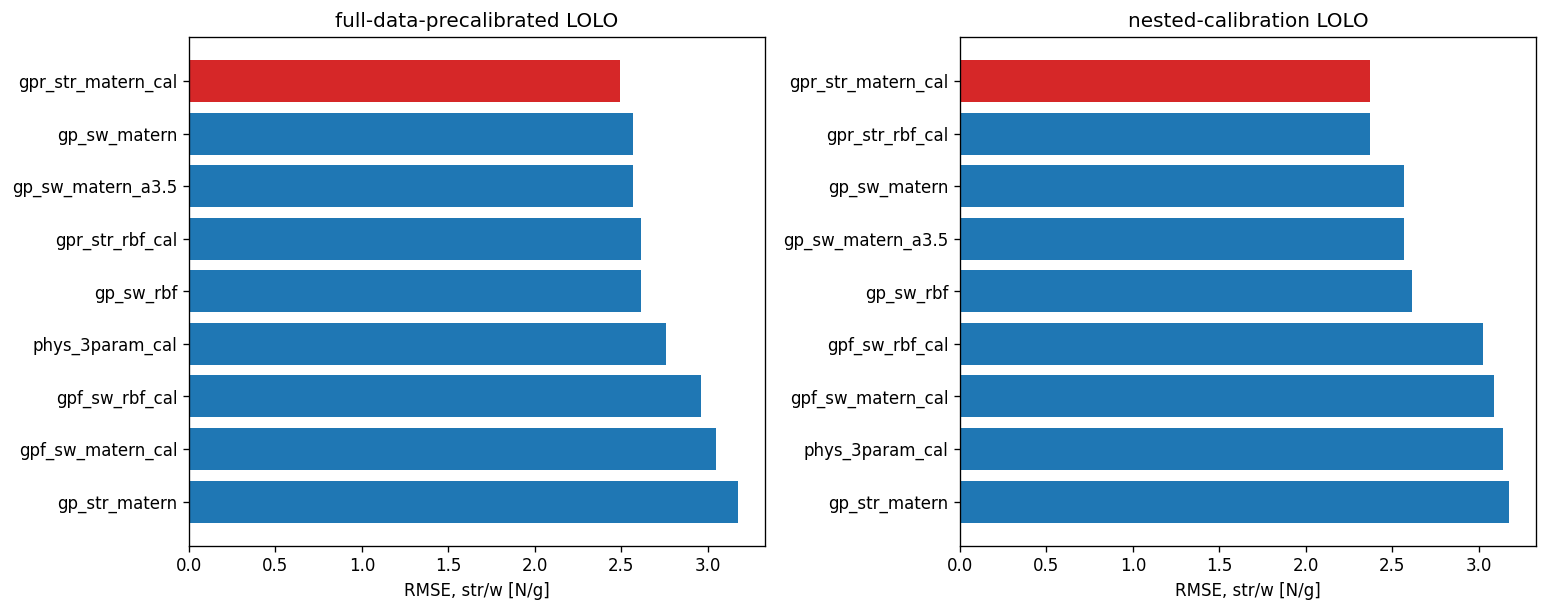

In [4]:
def metrics(y_true,y_pred,prefix=""):
    y_true,y_pred=np.asarray(y_true,float),np.asarray(y_pred,float); e=y_pred-y_true
    ss=np.sum((y_true-y_true.mean())**2)
    return {prefix+"rmse":float(np.sqrt(np.mean(e**2))),prefix+"mae":float(np.mean(abs(e))),
            prefix+"mape_pct":float(np.mean(abs(e/y_true))*100),prefix+"r2":float(1-np.sum(e**2)/ss)}

locs=allt["loc"].unique()
def lolo(kw):
    pred=np.zeros(len(allt))
    for L in locs:
        te=(allt["loc"]==L).values; m=BeamModel(**kw).fit(allt[~te])
        pred[te]=m.predict(allt.b.values[te],allt.H.values[te])[1]
    return pred

rows=[]
for name,kw in ZOO.items():
    p=lolo(kw); m={"model":name,**metrics(allt.sw_true,p,"sw_")}; rows.append(m)
    print(f"{name:22s} precal LOLO RMSE {m['sw_rmse']:.3f}  MAPE {m['sw_mape_pct']:.2f}%")
tbl=pd.DataFrame(rows).sort_values("sw_rmse").reset_index(drop=True)
winner=tbl.iloc[0]
print(f"\nPRECALIBRATED WINNER: {winner.model}, {winner.sw_rmse:.3f} N/g")

fold_cal={}
for L in locs:
    te=(allt["loc"]==L).values; fold_cal[L]=calibrate_physics(allt[~te])
nested_rows=[]
for name,kw in ZOO.items():
    if name not in PHYS_MODELS:
        r=tbl[tbl.model==name].iloc[0]
        nested_rows.append({"model":name,**{k:float(r[k]) for k in r.index if k!="model"}}); continue
    pred=np.zeros(len(allt))
    for L in locs:
        te=(allt["loc"]==L).values; fc=fold_cal[L]
        fkw=dict(kw,sy=fc["sy"],k=fc["k"],tau_i=fc["tau_i"])
        pred[te]=BeamModel(**fkw).fit(allt[~te]).predict(allt.b.values[te],allt.H.values[te])[1]
    m={"model":name,**metrics(allt.sw_true,pred,"sw_")}; nested_rows.append(m)
    print(f"{name:22s} nested LOLO RMSE {m['sw_rmse']:.3f}  MAPE {m['sw_mape_pct']:.2f}%")
nested=pd.DataFrame(nested_rows).sort_values("sw_rmse").reset_index(drop=True)
nested_winner=nested.iloc[0]
print(f"\nNESTED WINNER: {nested_winner.model}, {nested_winner.sw_rmse:.3f} N/g")
print(f"score shift for winner: {winner.sw_rmse-nested_winner.sw_rmse:+.3f} N/g "
      "(positive means the leaked score was pessimistic)")

# Audit the historical fixed-physics feature map without admitting it to the
# calibration-first selection table. Its tau_i was inferred from campaign
# responses outside these folds, so 2.216 N/g is not a nested estimate.
legacy_kw=dict(variant="gpf_sw",kernel_kind="matern",shear="new")
legacy_pred=lolo(legacy_kw); legacy=metrics(allt.sw_true,legacy_pred,"sw_")
print(f"LEGACY FIXED-PHYSICS AUDIT: {legacy['sw_rmse']:.3f} N/g RMSE / "
      f"{legacy['sw_mape_pct']:.2f}% MAPE (not an eligible calibration-first row)")

fig,ax=plt.subplots(1,2,figsize=(13,5.2),sharex=True)
for a,t,title in [(ax[0],tbl,"full-data-precalibrated LOLO"),(ax[1],nested,"nested-calibration LOLO")]:
    q=t.iloc[::-1]; colors=["tab:red" if m==t.iloc[0].model else "tab:blue" for m in q.model]
    a.barh(q.model,q.sw_rmse,color=colors); a.set_title(title); a.set_xlabel("RMSE, str/w [N/g]")
plt.tight_layout(); plt.show()

## 4. The selected ground truth

Both tables select **`gpr_str_matern_cal`**: a Matérn GP on

$$\log(P_{measured}/P_{phys,cal}),$$

with inputs `(b, H_web)`. The final GT first evaluates the fully calibrated
three-mode capacity, then multiplies it by the GP's learned residual factor.
The full-data calibration is σ_y = 65.242 MPa, k = 0.424578, and
τᵢ = 21.056 MPa.

This is a material change from the previous `gpf_sw_matern_sep` GT. Once the
physics surfaces are calibrated, treating physics as the multiplicative
baseline generalizes better than handing `log P_phys` to the GP as another
feature. The calibrated feature candidates score about 3.0 N/g RMSE, while the
calibrated residual model scores 2.494 N/g in the requested table and 2.368
N/g in the leak-free nested audit.

For comparison, the historical fixed-physics feature model reruns at 2.216
N/g / 5.30% LOLO, numerically better than the new nested score. It is not an
eligible calibration-first row: its fixed τᵢ was inferred from campaign
responses and then reused while those same locations were scored. The
fold-calibrated feature analogue, `gpf_sw_matern_cal`, scores 3.087 N/g. The
re-freeze therefore implements the requested modeling procedure but does not
prove an absolute accuracy gain over the legacy feature map.

The full-data-precalibrated score is information-leaked but, in this run,
**pessimistic** by 0.126 N/g rather than optimistic. The same formulation wins
both tables, so the model choice is not an artifact of the calibration leak.
The nested score is the defensible estimate of new-location accuracy; the
full-data constants are still the correct constants for the final model fit on
all available evidence.

GT optimum on 0.05 mm class grid: 42.17 N/g at (1.40, 12.10)
fitted GT kernel: 0.0741**2 * Matern(length_scale=[0.153, 0.368], nu=2.5)

GT values at the two frozen class designs:
equation beam    475.7 N   37.48 N/g
GP beam          445.8 N   36.65 N/g


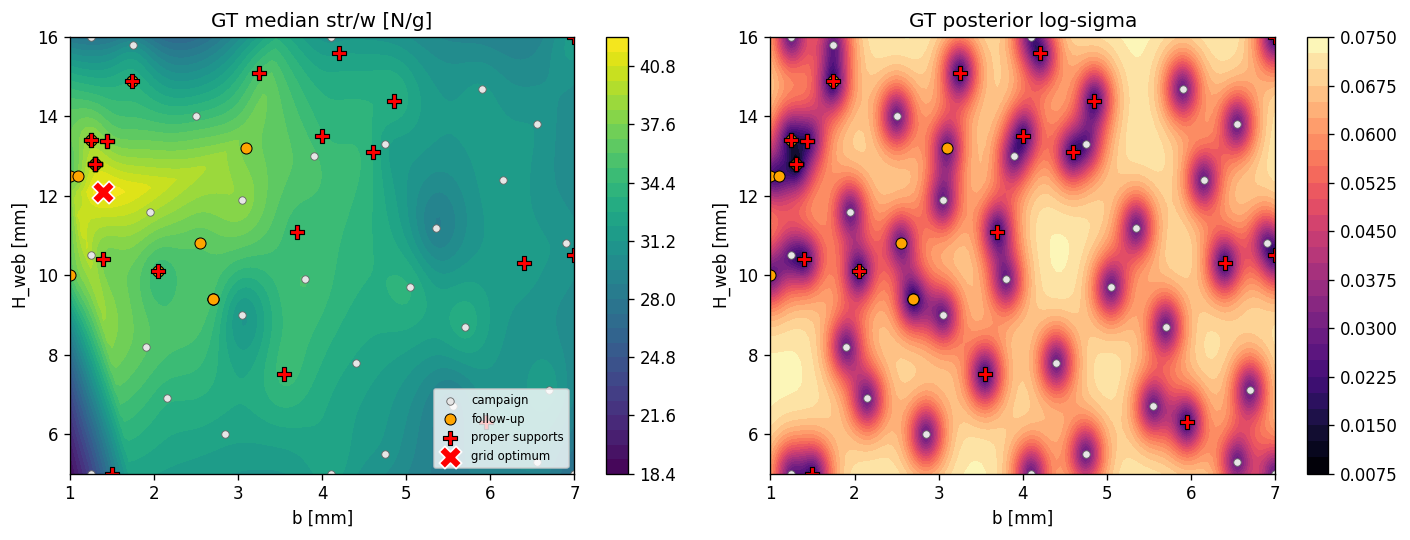

In [5]:
GT=BeamModel(**ZOO[winner.model]).fit(allt)
bg=np.linspace(B_LO,B_HI,121); Hg=np.linspace(H_LO,H_HI,111); BB,HH=np.meshgrid(bg,Hg)
_,swf,sigf=GT.predict(BB.ravel(),HH.ravel(),return_std=True)
SW,SIG=swf.reshape(BB.shape),sigf.reshape(BB.shape)
io=np.unravel_index(np.argmax(SW),SW.shape)
print(f"GT optimum on 0.05 mm class grid: {SW[io]:.2f} N/g at ({BB[io]:.2f}, {HH[io]:.2f})")
print("fitted GT kernel:",GT.gp.kernel_)

FROZEN=[((1.10,13.25),"equation beam",37.48,475.7),((1.00,13.39),"GP beam",36.65,445.8)]
print("\nGT values at the two frozen class designs:")
for (bq,Hq),label,sw0,s0 in FROZEN:
    s,sw=GT.predict([bq],[Hq]); print(f"{label:14s} {s[0]:7.1f} N  {sw[0]:6.2f} N/g")
    assert abs(s[0]-s0)<.15 and abs(sw[0]-sw0)<.015,(label,s[0],sw[0])

fig,ax=plt.subplots(1,2,figsize=(12,4.6))
mc,ma,mp=allt.source.eq("campaign"),allt.source.eq("followup"),allt.tag.eq("PS")
for a,Z,title,cmap in [(ax[0],SW,"GT median str/w [N/g]","viridis"),(ax[1],SIG,"GT posterior log-sigma","magma")]:
    cf=a.contourf(BB,HH,Z,levels=30,cmap=cmap); plt.colorbar(cf,ax=a)
    a.scatter(allt.b[mc],allt.H[mc],s=20,c=".9",edgecolor=".4",lw=.5,label="campaign")
    a.scatter(allt.b[ma],allt.H[ma],s=44,c="orange",edgecolor="k",lw=.6,label="follow-up")
    a.scatter(allt.b[mp],allt.H[mp],s=80,marker="P",c="red",edgecolor="k",lw=.7,label="proper supports")
    a.set(xlabel="b [mm]",ylabel="H_web [mm]",title=title)
ax[0].scatter([BB[io]],[HH[io]],marker="X",s=180,c="red",edgecolor="w",label="grid optimum")
ax[0].legend(fontsize=7,loc="lower right"); plt.tight_layout(); plt.show()

## 5. Caveats that should travel with this model

1. **Calibration before LOLO leaks response information.** The requested
   primary table holds full-data calibration constants fixed while locations
   leave the GP training set. The nested audit is therefore the accuracy
   estimate to quote. It selects the same model and scores it at 2.368 N/g
   RMSE / 5.41% MAPE. The leaked score is 2.494 N/g / 5.64% here—pessimistic,
   but still not unbiased.
2. **The legacy 2.216 N/g score is not an apples-to-apples nested audit.**
   Its response-derived τᵢ was frozen across folds. It is reported because it
   is numerically better and prevents an unsupported claim that calibration
   improved absolute accuracy; its fold-calibrated feature analogue scores
   3.087 N/g.
3. **The fitted parameters are effective structural parameters.** σ_y, k, and
   τᵢ jointly absorb printed-material behavior, fixture restraint, omitted
   failure physics, and support/session mix. They are not three independent
   coupon properties. τᵢ in particular varies substantially by print session
   and support condition.
4. **The support-condition mix remains unresolved.** The GT pools 60
   improper-support and 25 proper-support tests without a condition covariate.
   The controlled experiment found proper supports stronger and more
   repeatable at its anchor, and the recalibration batch showed a mode-
   dependent effect rather than one global scale factor.
5. **The thin-web frontier is sparse.** The widened b ≥ 1.0 box has only a
   small number of anchors near its new edge, several with flange–web
   separation. The GT optimum and both class queries lie in or near this
   frontier, so interpolation metrics do not fully measure their risk.
6. **Noise is structured.** Repeat pooling gives about 4.4%, whereas the GP
   uses 3%. Much of the excess is session/printer/support drift rather than
   iid print noise; changing one alpha cannot represent that hierarchy.
7. **The GT embeds the physics used downstream.** The winner multiplies its
   prediction by calibrated P_phys. Studies that score student physics-
   informed models against this GT are not fully independent of the same
   assumptions.
8. **The response-scale central value is a median.** The GP models a log
   response. Exponentiating its latent mean gives a posterior median, not an
   arithmetic mean. Frozen query values use that deterministic median.
9. **The LTB–separation blur remains a model discrepancy.** A clean minimum
   of independent modes cannot represent twisting that peels the joint. The
   residual GP can learn the mean knockdown where data exist, but its
   homoskedastic uncertainty does not encode random mode switching.

In [6]:
# Support/session context retained as a visible diagnostic.
print("proper-support versus old-support observations at shared geometries:")
for (b,H),g in allt.groupby(["b","H"]):
    if g.tag.eq("PS").any() and (~g.tag.eq("PS")).any():
        ps=g[g.tag.eq("PS")].strength_N; old=g[~g.tag.eq("PS")].strength_N
        print(f"  ({b:.2f},{H:.2f}): proper {ps.mean():.1f} N, old {old.mean():.1f} N")

frontier=allt[allt.b<=1.1]
print("\nthin-web frontier under the fully calibrated physics:")
for _,r in frontier.iterrows():
    P=phys_parts(r.b,r.H,CAL["sy"],CAL["k"],CAL["tau_i"])[3]
    print(f"  ({r.b:.2f},{r.H:.2f}): measured {r.strength_N:.1f} N, "
          f"P_phys {P:.1f} N, residual {100*(r.strength_N/P-1):+.1f}%")

proper-support versus old-support observations at shared geometries:
  (1.25,13.40): proper 511.2 N, old 485.8 N
  (1.30,12.80): proper 570.9 N, old 558.2 N
  (1.40,10.40): proper 724.1 N, old 654.6 N
  (1.50,5.00): proper 796.2 N, old 790.0 N
  (1.74,14.88): proper 376.1 N, old 399.1 N
  (2.05,10.10): proper 660.2 N, old 747.5 N
  (3.25,15.10): proper 543.6 N, old 588.8 N
  (3.55,7.50): proper 936.0 N, old 937.4 N
  (3.70,11.10): proper 821.5 N, old 741.3 N
  (4.00,13.50): proper 685.6 N, old 706.8 N
  (4.20,15.60): proper 588.5 N, old 582.6 N
  (4.60,13.10): proper 753.1 N, old 759.0 N
  (4.85,14.40): proper 736.7 N, old 724.1 N
  (5.95,6.30): proper 1020.7 N, old 918.4 N
  (6.40,10.30): proper 973.4 N, old 882.5 N
  (7.00,10.50): proper 921.1 N, old 948.8 N
  (7.00,16.00): proper 881.2 N, old 829.4 N

thin-web frontier under the fully calibrated physics:
  (1.00,10.00): measured 669.6 N, P_phys 618.2 N, residual +8.3%
  (1.00,12.50): measured 475.0 N, P_phys 619.8 N, residual -23.4%

### The LTB–separation blur corner: does the residual GP learn it?

The calibrated physics still treats separation and LTB as independent modes.
The tall-thin corner can couple them: twist peels the flange–web joint below
either pure capacity. Hold out each LTB-family location, recalibrate physics
on the remaining locations, fit the selected residual GP, and compare its
prediction with the recalibrated pure-physics baseline.

In [7]:
CORNER=[("print 3 — sep note, LTB-governed",1.25,16.0),
        ("print 35 — LTB note",1.75,15.8),("follow-up LTB trio",1.74,14.88)]
def at_loc(b,H): return np.isclose(allt.b,b,atol=.006)&np.isclose(allt.H,H,atol=.006)
print(f"{'location':<34} {'meas N':>7} {'Pphys':>7} {'GP':>7} {'GP err':>8}")
for label,b,H in CORNER:
    te=at_loc(b,H); train=allt[~te]; fc=calibrate_physics(train)
    kw=dict(variant="gpr_str",kernel_kind="matern",sy=fc["sy"],k=fc["k"],tau_i=fc["tau_i"])
    m=BeamModel(**kw).fit(train); s,_,sig=m.predict([b],[H],return_std=True)
    meas=allt.loc[te,"strength_N"].mean(); P=phys_parts(b,H,fc["sy"],fc["k"],fc["tau_i"])[3]
    print(f"{label:<34} {meas:7.0f} {P:7.0f} {s[0]:7.0f} {100*(s[0]/meas-1):+7.1f}%")

location                            meas N   Pphys      GP   GP err


print 3 — sep note, LTB-governed       226     208     213    -5.7%


print 35 — LTB note                    314     257     277   -11.8%


follow-up LTB trio                     391     344     383    -2.1%


The corner check is a deliberately small diagnostic, not a second model-
selection criterion. Its purpose is to show where the residual GP corrects a
calibrated pure-mode baseline and where it still extrapolates. The nested LOLO
table remains the population-level generalization evidence.

## 6. What survives a change of experiment: architecture lessons from the April studies

Before this campaign, the April 2-var ablations asked the same
model-architecture question under a genuinely different experiment: 8-inch
span, b ∈ [1, 8] × H_web ∈ [12, 23] with 16 mm flanges and 25 mm total
height, 27–44 beams, a different test stand, and handbook physics — ASTM
σ_y = 81.8 MPa, LTB at the full-span effective length with no fixture
factor, **no shear-failure formula at all in v1–v3** (while "web shear"
dominated the recorded failures; v4–v5 added the since-retired
average-web-shear and von Mises forms), no parameter calibration against
the beam tests, and near-zero assumed noise (α = 3e-5 – 1e-4).
Recommendations were scored against GP surrogates of the full dataset.
Reviewed 2026-07-21 specifically to separate lessons that replicate across
both experiments from conclusions that are artifacts of one dataset's
physics, box, or referee.

**Sources.** April era: `me323/ablation_study_2var.ipynb` and `_v2.ipynb`
(param/kernel/noise/acquisition factorials, 360 + 1200 runs),
`ablation_study_v4.ipynb` (direct vs residual, 2304 runs),
`ablation_v5_with_fantasy.ipynb` (one-step lookahead + physics-query
scenarios, 1152 rows), their CSVs (`ablation_results_2var*.csv`,
`ablation_followup_strength_v2_results (1).csv`),
`viz_gp_recs_n13.ipynb`, and `data/I_beam_data_2var.csv` +
`data/lhs16_subset_bH_even_n13.csv`. 150 mm era: this notebook's LOLO
tables, the student-scale LOO table in Submission 1, and the 160-combination
sweep in `ME323_Module1_Submission1_KnobSweep_FACULTY.ipynb`.

**Replicated in both experiments — safe to lean on:**

1. **Exploit-lean acquisition wins at these sample sizes.** April: EI ≫ UCB,
   with κ = 3 collapsing (strong-zone rate 0.14 vs 0.57 for EI in v1/v2).
   150 mm sweep: median GT outcome falls monotonically from MUI ψ = 0 to
   ψ = 2, EI worst. With ~13–17 points and a decent incumbent, uncertainty
   bonuses mostly buy bad beams.
2. **Assume more observation noise than the data admit to.** April:
   recommendation quality rose monotonically with assumed α, best at
   √(3e-3) ≈ 5.5%, worst at the ~0.5% default. 150 mm: repeats measure
   3–4.4% and noise is the second-most-important student knob. Both rigs
   point to an assumed-noise band near 3–6%; near-interpolation is the
   reproducible mistake.
3. **Physics pays most reliably as a query generator, not as model
   structure.** April: adding the physics-optimum as an extra (simulated)
   test lifted zone-hit rates 0.39 → 0.51 and rescued the hard 13-beam
   subset. 150 mm: the two-query class flow is this design, and the
   equation-query beam is the best of all 17. This is the most robust
   pro-physics result in either era.
4. **Physics inside the surrogate inherits the sign of its physics.**
   April: the residual family scored *better with the LTB term deleted*
   from its prior (`prior_gov_vm` > `prior_gov_full`) — the uncalibrated
   full-span LTB model was poisoning the baseline. 150 mm: the calibrated,
   fixture-aware three-mode residual (`gpr_str_matern_cal`) wins the nested
   LOLO outright. Same mechanism, opposite outcomes, decided by physics
   quality — "physics-informed" is not a virtue independent of calibration
   and mode correctness.
5. **The referee's family contaminates architecture rankings.** April v1
   scored against a plain-(b,H) GP and plain `b_H` had the best strong-zone
   rate (0.78); v2 switched the scorer to the 4-D physics-feature GP and
   the physics-feature parameterizations won instead (0.47–0.51 vs 0.27).
   This GT now shares lane D's formulation, so lane D's sweep margin is
   partly kinship; the GT-free 17-beam LOO table is the independent check.
6. **At n ≲ 20, architecture rankings are draw-dependent.** April: the
   winner flipped across 12-beam subsets (physics-feature configs swung
   20 ↔ 31 N/g median by draw) and between n13_even and n16_first in v4.
   150 mm: the Monte-Carlo study found subset quality rivals model choice.
   Only large margins (multiple N/g, reproduced under both kernels and
   across trims) deserve weight.

**Did not replicate — dataset-specific, do not teach as general:**

- **"Residual is the best architecture."** True here, with calibrated
  physics and a kindred referee; in April, direct vs residual was a wash
  (medians 29.0 vs 29.1 on n16_first) and residuals needed their worst
  physics term removed to compete.
- **"Strength-target models are catastrophic."** The 150 mm lane B failure
  requires a conjunction: an error-amplifying transform (÷ light mass), an
  optimizer attracted to the amplified region, and a real failure cliff
  there (LTB at H_web = 16). In April, raw-force direct models
  (`Pb_Pl_Pv_raw`) *won* on n16_first. Teach the conjunction test, not a
  target ban.
- **Kernel margins.** Matérn ≥ RBF in both eras, but it is the smallest
  effect everywhere (150 mm sweep: 1.1 N/g mean GT swing vs 9.9 for the
  lane). A defensible default, not a finding.
- **Edge-pick damage magnitude.** Direction replicates (April's
  explore-heavy configs landed far from anything tested; 150 mm edge picks
  median 33.7 vs 37.4 N/g interior), but the size of the penalty depends on
  what the box boundary happens to hide.

## Provenance

- **Data:** `data/ibeam150_master.csv`, 86 tests total and 85 usable after
  excluding one censored proper-support LTB test. The 10-test interleaved
  support experiment remains outside the GT training pool because adding ten
  repeats at one location would dominate location-level scoring.
- **Physics:** junction shear flow against printed-interface strength,
  documented in `ME323_Module1_Shear_Model_Selection_FACULTY.ipynb`.
- **2026-07-21 re-freeze:** full-data calibration gives σ_y = 65.242 MPa,
  k = 0.424578, τᵢ = 21.056 MPa. `gpr_str_matern_cal` wins both requested
  full-data-precalibrated LOLO (2.494 N/g) and leak-free nested-calibration
  LOLO (2.368 N/g). The legacy fixed-physics feature model's 2.216 N/g
  score is retained as a non-nested audit, not evidence that the re-freeze
  improved absolute predictive accuracy.
- **Frozen class results:** equation beam (1.10, 13.25) → 475.7 N =
  37.48 N/g; locked 3%-noise GP beam (1.00, 13.39) → 445.8 N = 36.65 N/g.
- **Consumption:** `ground_truth.py` is the staff record. `run13` regenerated
  all student and key notebooks and updated the noise-sensitivity narrative.
- **Before go-live:** this notebook and the campaign data come off the public
  repository so students cannot inspect the answer surface.